# FICA Guardian: Agentic KYC Compliance System

**Domain:** South African Banking — Know Your Customer (KYC) / FICA Compliance  
**Architecture:** Agentic RAG with LangChain Middleware (>v1.0.0)  
**LLM:** Groq (llama-3.3-70b-versatile) with Ollama (llama3.2:3b) fallback  
**Purpose:** Reduce manual KYC processing time and improve regulatory accuracy  

---

## System Architecture

```
PDF Bundle (ID + KYC Form + PoR)
        |
        v
  Document Ingestion (PyMuPDF + pyzbar)
        |
        v
  RAG Vector Store (FAISS + sentence-transformers)
        |
        v
  Agentic KYC Engine
  +-----------------------------------------+
  | ModelFallbackMiddleware  (Groq -> Ollama)|
  | ModelCallLimitMiddleware (run_limit=12)  |
  | ToolRetryMiddleware      (backoff)       |
  | TodoListMiddleware       (gate planning) |
  | KYCAuditMiddleware       (audit trail)   |
  |                                         |
  |  Gate 1: Identity Integrity             |
  |  Gate 2: Residency & Recency            |
  |  Gate 3: Database Risk Screening        |
  +-----------------------------------------+
        |
        v
  Pydantic KYCVerdict (structured output)
        |
        v
  Professional Compliance Report
```

---

**Reference Date for All Recency Checks:** 2026-03-25

## Section 0: Configuration & Environment

In [22]:
# ---------------------------------------------------------------------------
# CONFIGURATION CELL
# All tuneable parameters are declared here. Modify this cell to adjust
# thresholds, model settings, and processing behaviour without touching
# downstream pipeline code.
# ---------------------------------------------------------------------------

import os
from datetime import date

# --- LLM Settings -----------------------------------------------------------
GROQ_MODEL          = "llama-3.3-70b-versatile"
OLLAMA_MODEL        = "llama3.2:3b"
LLM_TEMPERATURE     = 0

# --- Rate Limiting & Safety -------------------------------------------------
MODEL_CALL_RUN_LIMIT        = 25    # Max model calls per client invocation
CLIENT_PROCESSING_DELAY_SEC = 3     # Seconds to wait between client batches

# --- RAG Settings -----------------------------------------------------------
EMBEDDING_MODEL     = "all-MiniLM-L6-v2"
CHUNK_SIZE          = 512
CHUNK_OVERLAP       = 64
RETRIEVAL_TOP_K     = 4
FAISS_INDEX_PATH    = "./faiss_kyc_index"

# --- KYC Business Logic -----------------------------------------------------
REFERENCE_DATE              = date(2026, 3, 25)   # Regulatory reference date
POR_MAX_AGE_DAYS            = 90                  # PoR currency threshold
ADDRESS_FUZZY_THRESHOLD     = 75                  # Minimum rapidfuzz score (0-100)

# --- File Paths -------------------------------------------------------------
DATA_DIR            = "./data"
IDS_DIR             = os.path.join(DATA_DIR, "ids")
KYC_FORMS_DIR       = os.path.join(DATA_DIR, "kyc_forms")
PORS_DIR            = os.path.join(DATA_DIR, "pors")
LOOKUP_DB_PATH      = os.path.join(DATA_DIR, "lookup", "fica_compliance.db")
REPORT_OUTPUT_PATH  = "./fica_guardian_report.md"

# --- Client IDs to Process --------------------------------------------------
# CLIENT_IDS = ["001", "002", "003", "004", "005"]
CLIENT_IDS = ["001"]

print("Configuration loaded.")
print(f"  Reference date : {REFERENCE_DATE}")
print(f"  Primary LLM    : {GROQ_MODEL} via Groq")
print(f"  Fallback LLM   : {OLLAMA_MODEL} via Ollama")
print(f"  Model call cap : {MODEL_CALL_RUN_LIMIT} per client")

Configuration loaded.
  Reference date : 2026-03-25
  Primary LLM    : llama-3.3-70b-versatile via Groq
  Fallback LLM   : llama3.2:3b via Ollama
  Model call cap : 25 per client


In [23]:
# ---------------------------------------------------------------------------
# DEPENDENCY IMPORTS
# All third-party imports are centralised here to surface missing packages
# early. Install via: uv add <package>
# ---------------------------------------------------------------------------

# Standard library
import re
import json
import time
import sqlite3
import logging
from pathlib import Path
from datetime import datetime, timedelta
from typing import Any, Callable, Optional
from dataclasses import dataclass, field

# PDF processing
import fitz                          # PyMuPDF
from pdf2image import convert_from_path
from pyzbar.pyzbar import decode as decode_barcode

# Data & fuzzy matching
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz import fuzz

# LangChain core
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

# LangChain agents & middleware (>v1.0.0 API)
from langchain.agents import create_agent
from langchain.agents.middleware import (
    AgentMiddleware,
    ModelFallbackMiddleware,
    ModelCallLimitMiddleware,
    ToolRetryMiddleware,
    TodoListMiddleware,
)
from langchain.agents.middleware import (
    AgentState,
    ModelRequest,
    ModelResponse,
)

# LangGraph checkpointer (required by ModelCallLimitMiddleware)
from langgraph.checkpoint.memory import InMemorySaver

# LLM providers
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama

# RAG components
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Pydantic v2 for structured output
from pydantic import BaseModel, Field

# Environment
from dotenv import load_dotenv
load_dotenv()

logging.basicConfig(level=logging.WARNING)  # Suppress verbose LangChain debug logs
logger = logging.getLogger("fica_guardian")

print("All imports successful.")

All imports successful.


## Section 1: Document Ingestion Layer

In [24]:
# ---------------------------------------------------------------------------
# DOCUMENT INGESTION
# Handles three document types per client:
#   1. ID Document  - Smart ID card (2-page) or Green Book (1-page)
#   2. KYC Form     - Bank-issued customer data capture form
#   3. Proof of Residence (PoR) - Utility bill, bank statement, lease, etc.
#
# CONFIRMED from diagnostic: ID PDFs contain rasterised images with no text
# layer (embedded 600x380 px DeviceRGB images, ASCII85Decode). OCR via
# pytesseract is the primary extraction path for all ID documents.
#
# KYC forms and PoR PDFs contain a native text layer and are extracted
# directly via PyMuPDF get_text(), which is fast and accurate for these.
#
# Rasterisation uses PyMuPDF's get_pixmap() at 3x scale (216 DPI effective)
# rather than pdf2image/poppler, eliminating the external poppler dependency
# for OCR. pdf2image is retained only for pyzbar barcode decoding where
# Poppler's renderer produces cleaner barcode region output.
#
# Barcode decoding: pyzbar on page rasterised at 300 DPI. The back face of
# a Smart ID contains a PDF417 barcode synthesised with a real Python lib.
# ---------------------------------------------------------------------------

import io
import pytesseract
from PIL import Image, ImageFilter, ImageOps

# Rasterisation scale factor for OCR: 3x = 216 DPI effective on 72pt PDF.
# Balances OCR accuracy against memory cost for the 600x380 source images.
# Increase to 4 (288 DPI) if Tesseract struggles with small fonts.
_OCR_SCALE      = 3
_OCR_SCALE_HIGH = 4   # Used for barcode rasterisation only

# Tesseract page segmentation mode:
#   psm 6 = Assume a single uniform block of text. Best for ID card fields.
#   psm 3 = Fully automatic (fallback for multi-column layouts).
_TESSERACT_CONFIG = "--oem 3 --psm 6"

# Minimum extracted character count to consider a page successfully read.
_TEXT_MIN_LENGTH = 15

# Keywords that identify the front face of a South African Smart ID card.
# Used to resolve random scan order (front/back not guaranteed).
_SMART_ID_FRONT_KEYWORDS = [
    "SURNAME", "NAMES", "NATIONALITY", "DATE OF BIRTH",
    "COUNTRY OF BIRTH", "IDENTITY NUMBER", "CITIZEN", "SEX",
]


def _rasterise_page(pdf_path: str, page_index: int, scale: int = _OCR_SCALE) -> Image.Image:
    """
    Rasterise a single PDF page to a PIL Image using PyMuPDF.

    Uses PyMuPDF's built-in renderer (no poppler dependency for OCR).
    The scale factor multiplies the native 72 DPI PDF coordinate space:
        scale=3 -> ~216 DPI,  scale=4 -> ~288 DPI.

    Args:
        pdf_path   : Path to the PDF file.
        page_index : Zero-based page index.
        scale      : Integer scale multiplier applied to 72pt base.

    Returns:
        PIL Image in RGB mode, ready for pytesseract or pyzbar.
    """
    with fitz.open(pdf_path) as doc:
        page = doc[page_index]
        mat  = fitz.Matrix(scale, scale)          # Uniform x/y scaling
        pix  = page.get_pixmap(matrix=mat, alpha=False)
        return Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")


def _preprocess_for_ocr(img: Image.Image) -> Image.Image:
    """
    Apply light preprocessing to improve Tesseract accuracy on ID card scans.

    Steps:
        1. Convert to greyscale (Tesseract works on greyscale internally).
        2. Apply a mild sharpening filter to enhance text edges that may
           have been softened during the original scan rasterisation.

    Deliberately minimal: heavy binarisation (e.g. Otsu threshold) can
    destroy light text on the green/gold Smart ID background gradients.
    """
    grey = ImageOps.grayscale(img)
    sharp = grey.filter(ImageFilter.SHARPEN)
    return sharp


def _ocr_page(pdf_path: str, page_index: int, scale: int = _OCR_SCALE) -> str:
    """
    OCR a single PDF page, trying multiple Tesseract PSM modes and returning
    the result with the highest character yield.

    PSM mode selection rationale for SA ID cards:
        psm 11 - Sparse text: reads all text found regardless of layout order.
                 Best for ID cards which have a label/value grid layout that
                 confuses block-based modes. Tried first.
        psm 6  - Uniform block: good fallback for single-column documents.
        psm 4  - Single column variable sizes.
        psm 3  - Fully automatic — last resort.
    """
    img      = _rasterise_page(pdf_path, page_index, scale)
    img_grey = _preprocess_for_ocr(img)

    best_text = ""
    for psm in [11, 6, 4, 3]:
        text = pytesseract.image_to_string(
            img_grey, config=f"--oem 3 --psm {psm}"
        ).strip()
        if len(text) > len(best_text):
            best_text = text
        if len(best_text) > 150:
            break   # Sufficient data — stop trying further modes

    logger.debug("_ocr_page: page %d | best psm yielded %d chars", page_index, len(best_text))
    return best_text


def _extract_page_text(pdf_path: str, page_index: int) -> str:
    """
    Extract text from a single PDF page using a two-strategy cascade.

    Strategy 1 (fast): PyMuPDF native text layer via get_text('text').
                       Works for KYC forms and PoR documents which have
                       embedded text objects.

    Strategy 2 (OCR):  pytesseract on a rasterised page image.
                       Activated when Strategy 1 returns fewer than
                       _TEXT_MIN_LENGTH characters, which is the confirmed
                       case for all ID document PDFs in this project.

    Args:
        pdf_path   : Path to the PDF file.
        page_index : Zero-based page index.

    Returns:
        Extracted text string.
    """
    # Strategy 1: native text layer (zero cost, instant)
    with fitz.open(pdf_path) as doc:
        native_text = doc[page_index].get_text("text").strip()

    if len(native_text) >= _TEXT_MIN_LENGTH:
        return native_text

    # Strategy 2: OCR fallback for image-based pages
    logger.debug("Native text empty for %s page %d — using OCR.", pdf_path, page_index)
    return _ocr_page(pdf_path, page_index)


def _classify_smart_id_pages(page0_text: str, page1_text: str) -> tuple[int, int]:
    """
    Determine which page is the front and which is the back of a Smart ID card.

    Scores each page against known front-face field keywords. The page with
    the higher keyword hit count is classified as the front. In the event of
    a tie, page 0 is assumed to be the front (most common scan convention).

    Returns:
        (front_page_index, back_page_index) as a tuple of 0-based integers.
    """
    def score(text: str, keywords: list) -> int:
        upper = text.upper()
        return sum(1 for kw in keywords if kw in upper)

    score_p0 = score(page0_text, _SMART_ID_FRONT_KEYWORDS)
    score_p1 = score(page1_text, _SMART_ID_FRONT_KEYWORDS)

    logger.debug("Smart ID page classifier: page0 score=%d, page1 score=%d",
                 score_p0, score_p1)

    if score_p0 >= score_p1:
        return 0, 1  # page 0 is front, page 1 is back
    return 1, 0      # page 1 is front, page 0 is back


# ---------------------------------------------------------------------------
# BARCODE DECODING
#
# Two decoders are used depending on ID document type — confirmed from the
# mock ID generation specification:
#
#   Smart ID card : PDF417 barcode on back face, decoded via pdf417decoder.
#                   Payload format: ID_NUMBER|SURNAME|FIRST_NAMES|COUNTRY_CODE
#                   pyzbar cannot decode this symbology from these mock PDFs.
#
#   Green Book    : Code 128 barcode at bottom of page, decoded via pyzbar.
#                   Payload: 13-digit ID number only.
#
# Both decoders operate on a PIL Image rasterised from the PDF page.
# ---------------------------------------------------------------------------

from pdf417decoder import PDF417Decoder


def _decode_smart_id_barcode(pdf_path: str, page_index: int) -> Optional[dict]:
    """
    Decode the PDF417 barcode from the back face of a Smart ID card.

    Uses the pdf417decoder library which handles the specific PDF417 variant
    used in the synthesised mock Smart ID documents.

    Payload structure (pipe-delimited):
        ID_NUMBER | SURNAME | FIRST_NAMES | COUNTRY_CODE

    Args:
        pdf_path   : Path to the ID PDF.
        page_index : Zero-based index of the back face page.

    Returns:
        dict with keys 'id_number', 'surname', 'first_names', 'country_code'
        and 'raw' (the full pipe-delimited string), or None if decode fails.
    """
    for scale in [4, 3, 6]:
        try:
            img     = _rasterise_page(pdf_path, page_index, scale=scale)
            decoder = PDF417Decoder(img)

            if decoder.decode() > 0:
                raw = decoder.barcode_data_index_to_string(0)
                logger.debug("PDF417 decoded at scale %dx: %r", scale, raw)

                parts = raw.split("|")
                if len(parts) >= 3:
                    return {
                        "id_number"   : parts[0].strip(),
                        "surname"     : parts[1].strip(),
                        "first_names" : parts[2].strip(),
                        "country_code": parts[3].strip() if len(parts) > 3 else "SA",
                        "raw"         : raw,
                    }
                else:
                    # Decoded but unexpected format — return raw for manual inspection
                    logger.warning("PDF417 decoded but unexpected format: %r", raw)
                    return {"id_number": None, "surname": None,
                            "first_names": None, "country_code": None, "raw": raw}

        except Exception as exc:
            logger.debug("PDF417 decode failed at scale %dx: %s", scale, exc)
            continue

    logger.warning("PDF417 barcode not decoded for %s page %d.", pdf_path, page_index)
    return None


def _decode_green_book_barcode(pdf_path: str, page_index: int = 0) -> Optional[str]:
    """
    Decode the Code 128 barcode from the bottom of a Green Book ID page.

    Uses pyzbar which handles Code 128 correctly. Filters explicitly for
    CODE128 symbology to avoid false positives from other barcode types.

    Args:
        pdf_path   : Path to the ID PDF.
        page_index : Zero-based page index (Green Books are single-page).

    Returns:
        13-digit ID number string, or None if decode fails.
    """
    from pyzbar.pyzbar import ZBarSymbol

    for scale in [4, 3, 6]:
        try:
            img    = _rasterise_page(pdf_path, page_index, scale=scale)
            # Crop bottom 30% where Code 128 barcode is positioned
            w, h   = img.size
            crop   = img.crop((0, int(h * 0.70), w, h))

            results = decode_barcode(crop, symbols=[ZBarSymbol.CODE128])
            if results:
                return results[0].data.decode("utf-8", errors="replace").strip()

            # Fallback: full page decode if crop yields nothing
            results = decode_barcode(img, symbols=[ZBarSymbol.CODE128])
            if results:
                return results[0].data.decode("utf-8", errors="replace").strip()

        except Exception as exc:
            logger.debug("Code128 decode failed at scale %dx: %s", scale, exc)
            continue

    logger.warning("Code 128 barcode not decoded for %s.", pdf_path)
    return None


def ingest_id_document(client_id: str) -> dict:
    """
    Ingest and classify an ID document for a given client.

    Enrichment strategy: when OCR yields limited text from the ID front face
    (common with image-based PDFs), the structured barcode data (id_number,
    surname, first_names) is appended to full_text in a labelled format.
    This ensures the agent always has the minimum fields needed for gate checks
    even when OCR is imperfect.

    Page count determines document type:
        1 page  -> Green Book. OCR + Code 128 barcode (ID number only).
        2 pages -> Smart ID. OCR both faces + PDF417 barcode (structured dict).
    """
    pdf_path = os.path.join(IDS_DIR, f"{client_id}_id.pdf")

    with fitz.open(pdf_path) as doc:
        page_count = len(doc)

    if page_count == 1:
        print(f"  [Ingest] Client {client_id}: OCR on Green Book...")
        text    = _extract_page_text(pdf_path, 0)
        barcode = _decode_green_book_barcode(pdf_path, 0)
        if barcode:
            print(f"  [Ingest] Client {client_id}: Code128 decoded -> {barcode}")
            # Append barcode ID to full_text so agent has it even if OCR missed it
            enriched = f"{text}\n[BARCODE]\nID Number: {barcode}"
        else:
            print(f"  [Ingest] Client {client_id}: Code128 not decoded")
            enriched = text
        return {
            "id_type"     : "green_book",
            "front_text"  : text,
            "back_text"   : None,
            "barcode_data": barcode,
            "full_text"   : enriched,
        }

    # Smart ID
    print(f"  [Ingest] Client {client_id}: OCR on Smart ID page 0...")
    page0_text = _extract_page_text(pdf_path, 0)
    print(f"  [Ingest] Client {client_id}: OCR on Smart ID page 1...")
    page1_text = _extract_page_text(pdf_path, 1)

    front_idx, back_idx = _classify_smart_id_pages(page0_text, page1_text)
    front_text = page0_text if front_idx == 0 else page1_text
    back_text  = page1_text if back_idx  == 1 else page0_text

    print(f"  [Ingest] Client {client_id}: front=page{front_idx}, back=page{back_idx}")
    print(f"  [Ingest] Client {client_id}: decoding PDF417 barcode...")

    barcode_dict = _decode_smart_id_barcode(pdf_path, back_idx)
    if barcode_dict:
        print(f"  [Ingest] Client {client_id}: PDF417 decoded -> "
              f"ID={barcode_dict['id_number']} | "
              f"{barcode_dict['surname']}, {barcode_dict['first_names']}")

        # Enrich full_text with structured barcode fields.
        # This is the authoritative source for Gate 1 checks when OCR
        # of the front face is incomplete due to image-based PDF rendering.
        barcode_enrichment = (
            f"\n[BARCODE - AUTHORITATIVE]\n"
            f"ID Number  : {barcode_dict['id_number']}\n"
            f"Surname    : {barcode_dict['surname']}\n"
            f"First Names: {barcode_dict['first_names']}\n"
            f"Country    : {barcode_dict['country_code']}\n"
        )
    else:
        print(f"  [Ingest] Client {client_id}: PDF417 not decoded — will flag in Gate 1.3")
        barcode_enrichment = "\n[BARCODE]: Not decoded.\n"

    full_text = f"[FRONT]\n{front_text}\n[BACK]\n{back_text}{barcode_enrichment}"

    return {
        "id_type"     : "smart_id",
        "front_text"  : front_text,
        "back_text"   : back_text,
        "barcode_data": barcode_dict,
        "full_text"   : full_text,
    }


def ingest_kyc_form(client_id: str) -> dict:
    """
    Extract all text from a KYC form PDF.

    KYC forms have a confirmed native text layer (652 chars, 18 blocks).
    Direct PyMuPDF extraction is used — no OCR required.
    """
    pdf_path = os.path.join(KYC_FORMS_DIR, f"{client_id}_kyc_form.pdf")
    texts = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            texts.append(page.get_text("text"))
    return {"full_text": "\n".join(texts).strip()}


def ingest_por(client_id: str) -> dict:
    """
    Extract all text from a Proof of Residence PDF.

    PoR documents have a confirmed native text layer (486 chars, 13 blocks).
    Direct PyMuPDF extraction is used — no OCR required.
    Filename pattern: {client_id}_por{N}.pdf (N matches client number).
    """
    por_dir = Path(PORS_DIR)
    matches = sorted(por_dir.glob(f"{client_id}_por*.pdf"))
    if not matches:
        raise FileNotFoundError(f"No PoR found for client {client_id} in {PORS_DIR}")
    pdf_path = str(matches[0])
    texts = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            texts.append(page.get_text("text"))
    return {"full_text": "\n".join(texts).strip()}


def ingest_client_bundle(client_id: str) -> dict:
    """
    Ingest the full document bundle for a client.

    Returns a dict keyed by document type, ready for RAG indexing
    and gate check tool injection.
    """
    print(f"  [Ingest] Client {client_id}: loading documents...")
    bundle = {
        "client_id": client_id,
        "id_doc"   : ingest_id_document(client_id),
        "kyc_form" : ingest_kyc_form(client_id),
        "por"      : ingest_por(client_id),
    }
    id_type = bundle["id_doc"]["id_type"]
    print(f"  [Ingest] Client {client_id}: complete ({id_type})")
    print(f"    ID front text  : {len(bundle['id_doc']['front_text'])} chars")
    print(f"    KYC form text  : {len(bundle['kyc_form']['full_text'])} chars")
    print(f"    PoR text       : {len(bundle['por']['full_text'])} chars")
    return bundle


print("Document ingestion functions defined.")
print("  ID PDFs   : OCR via pytesseract (image-only, no text layer)")
print("  KYC / PoR : native PyMuPDF text extraction")

Document ingestion functions defined.
  ID PDFs   : OCR via pytesseract (image-only, no text layer)
  KYC / PoR : native PyMuPDF text extraction


In [25]:
bundle=ingest_client_bundle("001")
bundle

  [Ingest] Client 001: loading documents...
  [Ingest] Client 001: OCR on Smart ID page 0...
  [Ingest] Client 001: OCR on Smart ID page 1...
  [Ingest] Client 001: front=page0, back=page1
  [Ingest] Client 001: decoding PDF417 barcode...
  [Ingest] Client 001: PDF417 decoded -> ID=8004237456087 | KHUMALO, SIPHO
  [Ingest] Client 001: complete (smart_id)
    ID front text  : 79 chars
    KYC form text  : 652 chars
    PoR text       : 486 chars


{'client_id': '001',
 'id_doc': {'id_type': 'smart_id',
  'front_text': 'LMG MUG\nBENT ARE ZZ.\n\nma\n\nLig Yj\n, OL TH AFR yy\n604 BH Yj\ntea + Vy — Y\nMie : Yy',
  'back_text': "1 |\n\n=\n\nAl\n\n_\n\n| i\n\n|\n\nIl\n\nIL\n\ni's\n\nI\n\nI\n\nf|\n\n‘Cer Number 156091587\n\nT<ZAF 800423745608 feceeecccecce\n\n$0042 3<M/45608 ZAP eccecceccccen?\n\nKHUMALO<<S0PHO<<<<e<ecee",
  'barcode_data': {'id_number': '8004237456087',
   'surname': 'KHUMALO',
   'first_names': 'SIPHO',
   'country_code': 'SA',
   'raw': '8004237456087|KHUMALO|SIPHO|SA'},
  'full_text': "[FRONT]\nLMG MUG\nBENT ARE ZZ.\n\nma\n\nLig Yj\n, OL TH AFR yy\n604 BH Yj\ntea + Vy — Y\nMie : Yy\n[BACK]\n1 |\n\n=\n\nAl\n\n_\n\n| i\n\n|\n\nIl\n\nIL\n\ni's\n\nI\n\nI\n\nf|\n\n‘Cer Number 156091587\n\nT<ZAF 800423745608 feceeecccecce\n\n$0042 3<M/45608 ZAP eccecceccccen?\n\nKHUMALO<<S0PHO<<<<e<ecee\n[BARCODE - AUTHORITATIVE]\nID Number  : 8004237456087\nSurname    : KHUMALO\nFirst Names: SIPHO\nCountry    : SA\n"},
 'kyc_form': {'fu

## Section 2: RAG Vector Store

In [26]:
# ---------------------------------------------------------------------------
# RAG VECTOR STORE
# Each client bundle is embedded into a per-session FAISS vector store.
# The agent retriever is used to pull relevant document passages when
# answering cross-document questions (e.g. address triangulation).
#
# Embedding model: all-MiniLM-L6-v2 (local, no API calls)
# Vector store: FAISS (persisted to disk per session)
# ---------------------------------------------------------------------------

_embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
_splitter   = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)


def build_client_vectorstore(bundle: dict) -> FAISS:
    """
    Build a FAISS vector store for a single client bundle.

    Each document section is tagged with metadata (source, client_id)
    to support filtered retrieval during gate checks.
    """
    client_id = bundle["client_id"]
    raw_docs = [
        Document(
            page_content=bundle["id_doc"]["full_text"],
            metadata={"source": "id_document", "client_id": client_id},
        ),
        Document(
            page_content=bundle["kyc_form"]["full_text"],
            metadata={"source": "kyc_form", "client_id": client_id},
        ),
        Document(
            page_content=bundle["por"]["full_text"],
            metadata={"source": "por", "client_id": client_id},
        ),
    ]

    # Chunk documents preserving metadata
    chunks = _splitter.split_documents(raw_docs)
    vectorstore = FAISS.from_documents(chunks, _embeddings)

    # Persist to disk for reproducibility and audit
    index_path = f"{FAISS_INDEX_PATH}_{client_id}"
    vectorstore.save_local(index_path)
    print(f"  [RAG] Client {client_id}: {len(chunks)} chunks indexed -> {index_path}")
    return vectorstore


def load_client_vectorstore(client_id: str) -> FAISS:
    """Load a previously persisted FAISS index for a client."""
    index_path = f"{FAISS_INDEX_PATH}_{client_id}"
    return FAISS.load_local(index_path, _embeddings,
                            allow_dangerous_deserialization=True)


print("RAG vector store functions defined.")
print(f"  Embedding model: {EMBEDDING_MODEL}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAG vector store functions defined.
  Embedding model: all-MiniLM-L6-v2


### Tool Schemas

In [27]:
class IdInput(BaseModel):
    kyc_id : str = Field(description="The ID number as written on the KYC submission form.")
    doc_id : str = Field(description="The ID number from the ID document barcode or OCR.")

class BarCodeInput(BaseModel):
    front_ocr_name: str = Field(description="The name as written on the front of the ID document.")
    barcode_data  : str = Field(description="The name as obtained from the barcode data on back of ID document.")


## Section 3: KYC Gate Check Tools

In [28]:
# ---------------------------------------------------------------------------
# GATE 1: STRUCTURAL IDENTITY INTEGRITY TOOLS
#
# Each tool is a discrete, independently callable function decorated with
# @tool from langchain_core. The agent invokes these tools autonomously
# during its reasoning loop.
#
# Tool inputs are plain Python types (str, dict) to ensure broad LLM
# compatibility without requiring structured tool call schemas.
# ---------------------------------------------------------------------------

@tool
def validate_id_format_and_luhn(id_number: str) -> dict:
    """
    Gate 1.1 — Validate South African ID number format and Luhn checksum.

    Format check (13 numeric digits) is a hard gate — failure means REJECTED.
    Luhn checksum is advisory in this implementation because synthesised test
    IDs may not carry valid Luhn checksums. In production, Luhn failure would
    escalate to REJECTED. Here it is recorded as a WARNING for audit purposes.

    Args:
        id_number: The 13-digit SA ID number to validate.

    Returns:
        dict with 'format_valid', 'luhn_valid', 'status', 'reason'
    """
    id_clean = str(id_number).strip().replace(" ", "")

    # Hard gate: format must be exactly 13 digits
    format_valid = bool(re.match(r"^[0-9]{13}$", id_clean))
    if not format_valid:
        return {
            "format_valid": False,
            "luhn_valid"  : False,
            "status"      : "REJECTED",
            "reason"      : f"ID '{id_clean}' does not match 13-digit numeric format.",
        }

    # Luhn algorithm
    digits = [int(d) for d in id_clean]
    total  = 0
    for i, d in enumerate(reversed(digits)):
        if i % 2 == 1:
            d *= 2
            if d > 9:
                d -= 9
        total += d
    luhn_valid = (total % 10 == 0)

    # Advisory: Luhn failure is a WARNING, not a REJECTED, for synthetic test data.
    # In production deployment, change status to "REJECTED" when luhn_valid is False.
    status = "PASS" if luhn_valid else "WARNING"
    reason = (
        "ID format valid and Luhn checksum confirmed."
        if luhn_valid else
        "ID format valid. Luhn checksum advisory warning — verify document authenticity."
    )

    return {
        "format_valid": True,
        "luhn_valid"  : luhn_valid,
        "status"      : status,
        "reason"      : reason,
    }



@tool(args_schema=IdInput)
def cross_match_id_number(kyc_id: str, doc_id: str) -> dict:
    """
    Gate 1.2 — Cross-match the ID number on the KYC form against the ID document.
    MUST use 'kyc_id' for the form data and 'doc_id' for the document data.
    both kyc_id and doc_id are south african id numbers for example '8004237456087'
    Args:
        kyc_id    : The ID number as written on the KYC submission form. Example correct usage is '8004237456087', incorrect usage is 'Sipho Khumalo'
        doc_id : The ID number from the ID document barcode or OCR. Example correct usage is '8004237456087',

    Returns:
        dict with 'match', 'status', 'reason'
    """
    form_clean = str(kyc_id).strip().replace(" ", "")
    doc_clean  = str(doc_id).strip().replace(" ", "")
    match      = (form_clean == doc_clean)

    return {
        "match" : match,
        "status": "PASS" if match else "REJECTED",
        "reason": (
            f"ID numbers match: {form_clean}."
            if match else
            f"Data mismatch: KYC form has '{form_clean}', ID document has '{doc_clean}'."
        ),
    }



@tool(args_schema=BarCodeInput)
def smart_id_barcode_integrity_check(
    front_ocr_name: str,
    barcode_data: Any,
    id_type: str,
) -> dict:
    """
    Gate 1.3 — Compare the name on the Smart ID front face against the back barcode.

    Input: barcode_data:
        - Must use a dict with keys 'surname' and 'first_names' (structured PDF417 output)
        - A plain string (raw barcode payload for fallback cases)
        - None (barcode not decoded)

    A name mismatch between the printed face and embedded barcode indicates
    identity tampering. Uses fuzzy matching to tolerate minor OCR variations.
    """
    if id_type.lower() in ("green_book", "green book"):
        return {
            "applicable": False,
            "match"     : None,
            "status"    : "N/A",
            "reason"    : "Green Book ID: barcode integrity check not applicable.",
        }

    # Normalise barcode_data to a comparable name string
    if barcode_data is None or barcode_data == "" or barcode_data == "Not decoded.":
        return {
            "applicable": True,
            "match"     : None,
            "status"    : "FLAG",
            "reason"    : "Smart ID: barcode not decoded. Manual review required.",
        }

    if isinstance(barcode_data, dict):
        surname     = barcode_data.get("surname") or barcode_data.get("Surname", "")
        first_names = barcode_data.get("first_names") or barcode_data.get("First Names", "")
        barcode_name = f"{surname} {first_names}".strip()
    else:
        # Plain string — use as-is
        barcode_name = str(barcode_data).strip()

    if not barcode_name:
        return {
            "applicable": True,
            "match"     : None,
            "status"    : "FLAG",
            "reason"    : "Barcode name fields are empty. Manual review required.",
        }

    score = fuzz.token_set_ratio(front_ocr_name.upper(), barcode_name.upper())
    match = score >= ADDRESS_FUZZY_THRESHOLD

    return {
        "applicable"  : True,
        "match"       : match,
        "fuzzy_score" : score,
        "barcode_name": barcode_name,
        "status"      : "PASS" if match else "CRITICAL_ALERT",
        "reason"      : (
            f"Front name '{front_ocr_name}' matches barcode '{barcode_name}' "
            f"(score: {score})."
            if match else
            f"CRITICAL: Name mismatch. Front='{front_ocr_name}' vs "
            f"Barcode='{barcode_name}' (score: {score}). Identity tampering suspected."
        ),
    }

@tool
def validate_age_dob_consistency(id_number: str, dob_on_form: str) -> dict:
    """
    Gate 1.4 — Verify that the date of birth embedded in the ID number matches the KYC form.

    South African ID structure: YYMMDD SSSS C A Z
    The first 6 digits encode the date of birth.

    Args:
        id_number  : 13-digit SA ID number
        dob_on_form: Date of birth as recorded on the KYC form (YYYY-MM-DD or DD/MM/YYYY)

    Returns:
        dict with 'dob_from_id', 'dob_from_form', 'match', 'status', 'reason'
    """
    id_clean = str(id_number).strip()
    if not re.match(r"^[0-9]{13}$", id_clean):
        return {"status": "ERROR", "reason": "Invalid ID number passed to DOB check."}

    yy = int(id_clean[0:2])
    mm = int(id_clean[2:4])
    dd = int(id_clean[4:6])

    # Determine century: FICA considers > current year (26) as 1900s
    year = 1900 + yy if yy > 26 else 2000 + yy
    dob_from_id = f"{year:04d}-{mm:02d}-{dd:02d}"

    # Normalise form date to YYYY-MM-DD
    form_clean = str(dob_on_form).strip()
    try:
        if "/" in form_clean:
            d, m, y = form_clean.split("/")
            dob_normalised = f"{y}-{m.zfill(2)}-{d.zfill(2)}"
        else:
            dob_normalised = form_clean
    except Exception:
        dob_normalised = form_clean

    match = (dob_from_id == dob_normalised)
    return {
        "dob_from_id"  : dob_from_id,
        "dob_from_form": dob_normalised,
        "match"        : match,
        "status"       : "PASS" if match else "FLAG",
        "reason"       : (
            "Date of birth is consistent across ID number and KYC form."
            if match else
            f"DOB mismatch: ID encodes '{dob_from_id}', form states '{dob_normalised}'."
        ),
    }


print("Gate 1 tools defined: validate_id_format_and_luhn, cross_match_id_number,")
print("  smart_id_barcode_integrity_check, validate_age_dob_consistency")

Gate 1 tools defined: validate_id_format_and_luhn, cross_match_id_number,
  smart_id_barcode_integrity_check, validate_age_dob_consistency


In [29]:
# ---------------------------------------------------------------------------
# GATE 2: RESIDENCY & RECENCY TOOLS
# ---------------------------------------------------------------------------

@tool
def classify_por_document(por_text: str) -> dict:
    """
    Gate 2.1 — Classify the type of Proof of Residence document.

    Supported types:
        - utility_bill      : Water, electricity, rates, or similar municipal accounts
        - bank_statement    : Statement issued by a registered bank
        - lease_agreement   : Rental/lease contract with expiry date
        - saps_affidavit    : South African Police Service sworn affidavit
        - unknown           : Could not classify

    Returns:
        dict with 'doc_type', 'confidence', 'status', 'reason'
    """
    text_upper = por_text.upper()

    classification_rules = [
        ("utility_bill"   , ["MUNICIPALITY", "ESKOM", "WATER", "ELECTRICITY",
                              "RATES", "ACCOUNT NUMBER", "METER","TAX INVOICE",
                               "MUNICIPAL STATEMENT","CITY OF JOHANNESBURG",
                                "CITY OF CAPE TOWN","TSHWANE","EKURHULENI","RATES AND TAXES" ]),
        ("bank_statement" , ["BANK STATEMENT", "BRANCH CODE", "ACCOUNT HOLDER",
                              "OPENING BALANCE", "CLOSING BALANCE", "TRANSACTION"]),
        ("lease_agreement", ["LEASE", "RENTAL AGREEMENT", "TENANT", "LANDLORD",
                              "EXPIRY DATE", "LEASE PERIOD"]),
        ("saps_affidavit" , ["SOUTH AFRICAN POLICE", "AFFIDAVIT", "SWORN",
                              "COMMISSIONER OF OATHS", "SAPS"]),
    ]

    scores = {}
    for doc_type, keywords in classification_rules:
        scores[doc_type] = sum(1 for kw in keywords if kw in text_upper)

    best_type  = max(scores, key=scores.get)
    best_score = scores[best_type]

    if best_score == 0:
        return {
            "doc_type"  : "unknown",
            "confidence": 0,
            "status"    : "FLAG",
            "reason"    : "PoR document type could not be classified.",
        }

    return {
        "doc_type"  : best_type,
        "confidence": best_score,
        "status"    : "PASS",
        "reason"    : f"Document classified as '{best_type}' with confidence score {best_score}.",
    }


@tool
def check_90_day_currency_rule(por_text: str, doc_type: str) -> dict:
    """
    Gate 2.2 — Verify that the PoR document is within the 90-day currency window.

    Reference date: 2026-03-25.
    For lease agreements, the expiry date must be in the future (not the issue date).

    Returns:
        dict with 'doc_date', 'days_old', 'within_90_days', 'status', 'reason'
    """
    # Pattern to detect dates in common South African document formats
    date_patterns = [
        (r"(\d{4})[-/](\d{2})[-/](\d{2})", "%Y-%m-%d"),  # YYYY-MM-DD
        (r"(\d{2})[-/](\d{2})[-/](\d{4})", "%d-%m-%Y"),  # DD-MM-YYYY
        (r"(\d{1,2})\s+([A-Za-z]+)\s+(\d{4})", None),    # DD Month YYYY
    ]

    months = {"january":1,"february":2,"march":3,"april":4,"may":5,"june":6,
              "july":7,"august":8,"september":9,"october":10,"november":11,"december":12}

    found_dates = []

    # Extract YYYY-MM-DD and DD-MM-YYYY patterns
    for pattern, fmt in date_patterns[:2]:
        for m in re.finditer(pattern, por_text):
            try:
                found_dates.append(datetime.strptime(m.group(0).replace("/","-"), fmt).date())
            except ValueError:
                pass

    # Extract DD Month YYYY patterns
    for m in re.finditer(r"(\d{1,2})\s+([A-Za-z]+)\s+(\d{4})", por_text):
        try:
            day  = int(m.group(1))
            mon  = months.get(m.group(2).lower())
            year = int(m.group(3))
            if mon:
                found_dates.append(date(year, mon, day))
        except (ValueError, TypeError):
            pass

    if not found_dates:
        return {
            "doc_date"      : None,
            "days_old"      : None,
            "within_90_days": False,
            "status"        : "FLAG",
            "reason"        : "No valid date found in PoR document. Manual review required.",
        }

    if doc_type == "lease_agreement":
        # For leases, use the latest date found (expiry date)
        relevant_date = max(found_dates)
        is_valid = relevant_date > REFERENCE_DATE
        return {
            "doc_date"      : str(relevant_date),
            "days_old"      : (REFERENCE_DATE - relevant_date).days,
            "within_90_days": is_valid,
            "status"        : "PASS" if is_valid else "REJECTED",
            "reason"        : (
                f"Lease agreement expiry {relevant_date} is in the future."
                if is_valid else
                f"Lease agreement expired on {relevant_date}."
            ),
        }

    # For other doc types, use the most recent date (issue/statement date)
    relevant_date = max(found_dates)
    days_old = (REFERENCE_DATE - relevant_date).days
    within_90 = days_old <= POR_MAX_AGE_DAYS

    return {
        "doc_date"      : str(relevant_date),
        "days_old"      : days_old,
        "within_90_days": within_90,
        "status"        : "PASS" if within_90 else "REJECTED",
        "reason"        : (
            f"PoR dated {relevant_date} is {days_old} days old (within 90-day limit)."
            if within_90 else
            f"PoR dated {relevant_date} is {days_old} days old. EXCEEDS 90-day limit."
        ),
    }


@tool
def check_physicality_of_address(por_text: str) -> dict:
    """
    Gate 2.3 — Reject PoR documents where the address is only a PO Box.

    FICA requires a physical street address for residential verification.
    PO Boxes are not acceptable as proof of physical residence.

    Returns:
        dict with 'is_po_box', 'has_street_address', 'status', 'reason'
    """
    text_upper = por_text.upper()
    is_po_box = bool(re.search(r"\bP\.?O\.?\s*BOX\b", text_upper))

    # Check for presence of a street-type indicator
    street_indicators = [
        r"\b\d+\s+[A-Z][A-Z\s]+(?:STREET|ST|ROAD|RD|AVENUE|AVE|DRIVE|DR|"
        r"CLOSE|CL|LANE|LN|CRESCENT|CR|BOULEVARD|BLVD|PLACE|PL|COURT|CT)\b"
    ]
    has_street = any(re.search(p, text_upper) for p in street_indicators)

    # Only reject if it is EXCLUSIVELY a PO Box with no street address
    reject = is_po_box and not has_street

    return {
        "is_po_box"        : is_po_box,
        "has_street_address": has_street,
        "status"           : "REJECTED" if reject else "PASS",
        "reason"           : (
            "PoR contains only a PO Box. Physical street address required by FICA."
            if reject else
            "Physical street address confirmed in PoR document."
        ),
    }


@tool
def fuzzy_address_triangulation(address_on_form: str, address_on_por: str) -> dict:
    """
    Gate 2.4 — Fuzzy match the residential address on the KYC form against the PoR.

    Uses rapidfuzz token_set_ratio to tolerate abbreviations and ordering differences
    (e.g. 'Str' vs 'Street', '10 Main' vs 'Main Street 10').

    Returns:
        dict with 'score', 'threshold', 'match', 'status', 'reason'
    """
    score = fuzz.token_set_ratio(address_on_form.upper(), address_on_por.upper())
    match = score >= ADDRESS_FUZZY_THRESHOLD

    return {
        "score"    : score,
        "threshold": ADDRESS_FUZZY_THRESHOLD,
        "match"    : match,
        "status"   : "PASS" if match else "FLAG",
        "reason"   : (
            f"Addresses are consistent (fuzzy score: {score}/{ADDRESS_FUZZY_THRESHOLD})."
            if match else
            f"Address mismatch detected (fuzzy score: {score}/{ADDRESS_FUZZY_THRESHOLD}). "
            "Manual review recommended."
        ),
    }


print("Gate 2 tools defined: classify_por_document, check_90_day_currency_rule,")
print("  check_physicality_of_address, fuzzy_address_triangulation")

Gate 2 tools defined: classify_por_document, check_90_day_currency_rule,
  check_physicality_of_address, fuzzy_address_triangulation


In [30]:
# ---------------------------------------------------------------------------
# GATE 3: DATABASE RISK SCREENING TOOLS
#
# All lookups target the SQLite database at LOOKUP_DB_PATH.
# Connection is opened and closed per call to avoid long-lived connections
# during the agent loop.
# ---------------------------------------------------------------------------

def _db_query(sql: str, params: tuple) -> list[dict]:
    """
    Execute a parameterised query against the FICA compliance database.
    Returns a list of row dicts. Raises on connection or query failure.
    """
    with sqlite3.connect(LOOKUP_DB_PATH) as conn:
        conn.row_factory = sqlite3.Row
        cursor = conn.execute(sql, params)
        return [dict(row) for row in cursor.fetchall()]


@tool
def sanctions_list_lookup(id_number: str) -> dict:
    """
    Gate 3.1 — Query the sanctions_list table by ID number.

    Any sanctions hit results in immediate rejection regardless of other gate outcomes.
    Sanctions screening is a mandatory AML control under FICA Section 28.

    Returns:
        dict with 'hit', 'records', 'status', 'reason'
    """
    try:
        rows = _db_query(
            "SELECT full_name, id_number, risk_level, reason "
            "FROM sanctions_list WHERE id_number = ?",
            (str(id_number).strip(),)
        )
        hit = len(rows) > 0
        return {
            "hit"    : hit,
            "records": rows,
            "status" : "REJECTED" if hit else "PASS",
            "reason" : (
                f"SANCTIONS HIT: {rows[0]['full_name']} — {rows[0]['reason']}"
                if hit else
                "No sanctions match found for this ID number."
            ),
        }
    except Exception as exc:
        return {"hit": None, "status": "ERROR", "reason": str(exc)}


@tool
def pep_registry_lookup(full_name: str) -> dict:
    """
    Gate 3.2 — Query the pep_registry table by full name.

    A PEP (Politically Exposed Person) match triggers Enhanced Due素质 Diligence (EDD).
    The client is not rejected but flagged for additional scrutiny per FATF guidelines.

    Returns:
        dict with 'hit', 'is_active', 'position', 'status', 'reason'
    """
    try:
        # Use LIKE for partial name matching to tolerate middle name omissions
        name_parts = str(full_name).strip().split()
        if not name_parts:
            return {"hit": False, "status": "PASS", "reason": "No name provided."}

        surname = name_parts[-1]
        rows = _db_query(
            "SELECT full_name, id_number, position, is_active "
            "FROM pep_registry WHERE full_name LIKE ?",
            (f"%{surname}%",)
        )

        # Secondary filter: check first name also matches
        if rows and len(name_parts) > 1:
            first = name_parts[0].upper()
            rows = [r for r in rows if first in r["full_name"].upper()]

        hit = len(rows) > 0
        if hit:
            record = rows[0]
            return {
                "hit"      : True,
                "is_active": record["is_active"],
                "position" : record["position"],
                "status"   : "FLAG_EDD",
                "reason"   : (
                    f"PEP MATCH: {record['full_name']} — Position: {record['position']}. "
                    "Enhanced Due Diligence required."
                ),
            }

        return {
            "hit"      : False,
            "is_active": None,
            "position" : None,
            "status"   : "PASS",
            "reason"   : "No PEP registry match found for this name.",
        }
    except Exception as exc:
        return {"hit": None, "status": "ERROR", "reason": str(exc)}


@tool
def bank_reference_check(branch_code: str, doc_type: str) -> dict:
    """
    Gate 3.3 — Validate a bank branch code if the PoR is a bank statement.

    Only applicable when the PoR has been classified as a bank statement.
    An unrecognised branch code may indicate a fraudulent statement.

    Returns:
        dict with 'applicable', 'bank_name', 'valid', 'status', 'reason'
    """
    if doc_type != "bank_statement":
        return {
            "applicable": False,
            "status"    : "N/A",
            "reason"    : f"PoR is '{doc_type}'. Bank reference check not applicable.",
        }

    try:
        code_clean = str(branch_code).strip().replace(" ", "")
        rows = _db_query(
            "SELECT bank_name, branch_code FROM bank_reference WHERE branch_code = ?",
            (code_clean,)
        )
        valid = len(rows) > 0
        return {
            "applicable": True,
            "bank_name" : rows[0]["bank_name"] if valid else None,
            "valid"     : valid,
            "status"    : "PASS" if valid else "FLAG",
            "reason"    : (
                f"Branch code {code_clean} confirmed: {rows[0]['bank_name']}."
                if valid else
                f"Branch code {code_clean} not found in registered bank reference table."
            ),
        }
    except Exception as exc:
        return {"applicable": True, "valid": None, "status": "ERROR", "reason": str(exc)}


print("Gate 3 tools defined: sanctions_list_lookup, pep_registry_lookup, bank_reference_check")

Gate 3 tools defined: sanctions_list_lookup, pep_registry_lookup, bank_reference_check


In [31]:
# ---------------------------------------------------------------------------
# TOOL REGISTRY
# Aggregate all gate tools into a single list for agent registration.
# ---------------------------------------------------------------------------

KYC_TOOLS = [
    # Gate 1
    validate_id_format_and_luhn,
    cross_match_id_number,
    smart_id_barcode_integrity_check,
    validate_age_dob_consistency,
    # Gate 2
    classify_por_document,
    check_90_day_currency_rule,
    check_physicality_of_address,
    fuzzy_address_triangulation,
    # Gate 3
    sanctions_list_lookup,
    pep_registry_lookup,
    bank_reference_check,
]

print(f"Tool registry: {len(KYC_TOOLS)} tools registered across 3 gates.")

Tool registry: 11 tools registered across 3 gates.


## Section 4: LangChain Middleware & Agent Construction

In [32]:
# ---------------------------------------------------------------------------
# CUSTOM MIDDLEWARE: KYCAuditMiddleware
#
# Implements the LangChain >v1.0.0 AgentMiddleware interface using the
# verified decorator-based lifecycle hooks:
#
#   before_agent  -> initialise per-client audit record
#   after_agent   -> finalise audit record with wall-clock time
#   before_model  -> record model call start timestamp
#   after_model   -> capture token usage and active LLM identity
#   wrap_tool_call-> time each gate check and log pass/fail verdicts
#
# The class-based pattern is used (not standalone @decorator functions)
# because the audit log requires shared mutable state across multiple hooks.
# ---------------------------------------------------------------------------

class KYCAuditMiddleware(AgentMiddleware):
    """
    Lifecycle middleware that produces a structured audit trail for each
    KYC client invocation.

    Captures:
        - Per-model-call token usage (input, output, total)
        - Which LLM served each request (Groq vs Ollama fallback)
        - Per-tool-call gate verdicts and latency
        - Total agent wall-clock time

    The populated audit_records list is accessed after all clients are
    processed to generate the analytics section.
    """

    def __init__(self):
        self.audit_records: list[dict] = []
        self._current: dict = {}          # Active client record during agent run
        self._model_call_start: float = 0.0

    def before_agent(self, state: AgentState, runtime) -> dict | None:
        """
        Initialise a fresh audit record for the incoming client.
        Extracts client_id from the first HumanMessage in the state.
        """
        # Attempt to extract client_id from the agent input message
        client_id = "unknown"
        messages = state.get("messages", [])
        if messages:
            content = str(messages[0].content)
            match = re.search(r"client[_\s]?id[:\s]+([0-9]{3})", content, re.IGNORECASE)
            if match:
                client_id = match.group(1)

        self._current = {
            "client_id"         : client_id,
            "agent_start_time"  : time.time(),
            "model_calls"       : [],
            "tool_calls"        : [],
            "total_input_tokens": 0,
            "total_output_tokens": 0,
            "total_tokens"      : 0,
            "wall_clock_sec"    : None,
        }
        return None  # Continue normal execution

    def after_agent(self, state: AgentState, runtime) -> dict | None:
        """Finalise the audit record and append to the session log."""
        if self._current:
            self._current["wall_clock_sec"] = round(
                time.time() - self._current["agent_start_time"], 2
            )
            self.audit_records.append(dict(self._current))
            self._current = {}
        return None

    def before_model(self, state: AgentState, runtime) -> dict | None:
        """Record the start timestamp immediately before a model invocation."""
        self._model_call_start = time.time()
        return None

    def after_model(self, state: AgentState, runtime) -> dict | None:
        """
        Capture token usage from the last AI message after a model call.

        LangChain >v1.0.0 stores usage metadata in AIMessage.usage_metadata:
            {'input_tokens': int, 'output_tokens': int, 'total_tokens': int}
        The model ID is available in AIMessage.response_metadata['model'].
        """
        latency_ms = round((time.time() - self._model_call_start) * 1000)
        messages   = state.get("messages", [])
        call_record = {"latency_ms": latency_ms, "model": "unknown",
                       "input_tokens": 0, "output_tokens": 0, "total_tokens": 0}

        # Find the last AIMessage to extract usage metadata
        from langchain_core.messages import AIMessage
        for msg in reversed(messages):
            if isinstance(msg, AIMessage):
                usage = getattr(msg, "usage_metadata", {}) or {}
                call_record["input_tokens"]  = usage.get("input_tokens", 0)
                call_record["output_tokens"] = usage.get("output_tokens", 0)
                call_record["total_tokens"]  = usage.get("total_tokens", 0)
                resp_meta = getattr(msg, "response_metadata", {}) or {}
                call_record["model"] = resp_meta.get("model", "unknown")
                break

        if self._current:
            self._current["model_calls"].append(call_record)
            self._current["total_input_tokens"]  += call_record["input_tokens"]
            self._current["total_output_tokens"] += call_record["output_tokens"]
            self._current["total_tokens"]        += call_record["total_tokens"]
        return None

    def wrap_tool_call(self, request, handler: Callable) -> Any:
        """
        Wrap each KYC gate tool call to capture name, latency, and verdict.

        The handler callback represents all inner middleware layers.
        This follows the wrap_tool_call contract: call handler(request) and
        return its result, adding instrumentation around it.
        """
        print(f"wrap_tool_call: request: {request}")
        tool_name  = getattr(request, "name", "unknown_tool")
        start_time = time.time()

        result = handler(request)  # Execute the actual tool
        print(f"wrap_tool_call: result: {result}")

        latency_ms = round((time.time() - start_time) * 1000)

        # Attempt to extract a status verdict from the tool output
        verdict = "UNKNOWN"
        try:
            # Tool results arrive as ToolMessage; content may be JSON
            content = getattr(result, "content", "{}")
            parsed  = json.loads(content) if isinstance(content, str) else content
            verdict = parsed.get("status", "UNKNOWN") if isinstance(parsed, dict) else "UNKNOWN"
        except (json.JSONDecodeError, AttributeError):
            pass

        tool_record = {
            "tool"      : tool_name,
            "verdict"   : verdict,
            "latency_ms": latency_ms,
        }

        if self._current:
            self._current["tool_calls"].append(tool_record)

        return result


print("KYCAuditMiddleware defined with hooks: before_agent, after_agent,")
print("  before_model, after_model, wrap_tool_call")

KYCAuditMiddleware defined with hooks: before_agent, after_agent,
  before_model, after_model, wrap_tool_call


### SYSTEM PROMPTS

In [33]:
# ---------------------------------------------------------------------------
# SYSTEM PROMPTS
# ---------------------------------------------------------------------------

FICA_SYSTEM_PROMPT = """
You are FICA Guardian, a specialist KYC compliance verification agent operating
under the South African Financial Intelligence Centre Act (FICA) and the Financial
Action Task Force (FATF) Recommendations.

CRITICAL: Execute ONE tool at a time. Wait for each tool result before calling
the next tool. Do not batch multiple tool calls in a single response.

REFERENCE DATE: 2026-03-25

DATA EXTRACTION RULES (read before calling any tool):
  - ID Number : Extract ONLY from the line starting 'ID Number :' under
                [BARCODE - AUTHORITATIVE]. Never use MRZ lines (T<ZAF...).
  - Name      : For Gate 1.3, use 'Surname' and 'First Names' from
                [BARCODE - AUTHORITATIVE], concatenated as 'SURNAME FIRSTNAMES'.
  - PEP lookup: Use Full Names from the KYC FORM section only.
  - Address   : Extract from KYC FORM for form address, PoR section for PoR address.

GATE EXECUTION ORDER (one tool call per step):
  Step  1: validate_id_format_and_luhn     (use barcode ID number)
  Step  2: cross_match_id_number           (use kyc_id and doc_id Example correct usage is '8004237456087', incorrect usage is 'Sipho Khumalo)
  Step  3: smart_id_barcode_integrity_check ('front_ocr_name' vs 'barcode_data', must usage parameter 'barcode_data' with fields 'surname' and 'firstnames'. do not use parameter 'barcode_name')
  Step  4: validate_age_dob_consistency    (barcode ID vs KYC form DOB)
  Step  5: classify_por_document           (full PoR text)
  Step  6: check_90_day_currency_rule      (full PoR text + doc_type from step 5)
  Step  7: check_physicality_of_address    (full PoR text)
  Step  8: fuzzy_address_triangulation     (KYC address vs PoR address)
  Step  9: sanctions_list_lookup           (barcode ID number)
  Step 10: pep_registry_lookup             (full name from KYC form)
  Step 11: bank_reference_check            (branch code if applicable, doc_type from step 5)

VERDICT DECISION LOGIC:
  APPROVED     : All gate checks pass with no flags.
  REJECTED     : Any single check returns REJECTED status. Luhn WARNING alone does not cause rejection — it is recorded in findings only.
  CRITICAL_ALERT: Barcode name mismatch on Smart ID (identity tampering).
  FLAG_EDD     : PEP registry hit — Enhanced Due Diligence required.
  MANUAL_REVIEW: Unresolvable flag (PO Box only, unreadable barcode, etc.)

OUTPUT: After step 11, return a single JSON object:
{
  "client_id": "<id>",
  "final_verdict": "<APPROVED|REJECTED|CRITICAL_ALERT|FLAG_EDD|MANUAL_REVIEW>",
  "risk_level": "<LOW|MEDIUM|HIGH|CRITICAL>",
  "gate_results": {
    "gate_1": {"status": "<PASS|FAIL>", "findings": ["...", "..."]},
    "gate_2": {"status": "<PASS|FAIL>", "findings": ["...", "..."]},
    "gate_3": {"status": "<PASS|FAIL>", "findings": ["...", "..."]}
  },
  "recommended_action": "<specific action>",
  "audit_timestamp": "<ISO-8601>"
}
Do not output anything outside the JSON object.
"""

# FICA_TODO_PROMPT is retained as documentation of the gate tracking design.
# It is not injected into the agent because TodoListMiddleware's write_todos
# schema (list[dict]) causes Llama-3.3-70b to serialise tool calls as text
# rather than structured function calls, halting the agent loop.
# This prompt would be re-enabled when using an OpenAI-compatible model.

print("System prompts defined.")

System prompts defined.


In [34]:
# ---------------------------------------------------------------------------
# LLM INITIALISATION
# Groq (primary) and Ollama (fallback) are instantiated here.
# The GROQ_API_KEY is loaded from the .env file via python-dotenv.
# ---------------------------------------------------------------------------

groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise EnvironmentError(
        "GROQ_API_KEY not found in environment. "
        "Add it to your .env file: GROQ_API_KEY=<your-key>"
    )

fallback_llm = ChatGroq(
    model=GROQ_MODEL,
    temperature=LLM_TEMPERATURE,
    groq_api_key=groq_api_key,
)

primary_llm = ChatOllama(
    model=OLLAMA_MODEL,
    temperature=LLM_TEMPERATURE,
)

print(f"Primary LLM  : {GROQ_MODEL} (Groq)")
print(f"Fallback LLM : {OLLAMA_MODEL} (Ollama)")

Primary LLM  : llama-3.3-70b-versatile (Groq)
Fallback LLM : llama3.2:3b (Ollama)


In [35]:
# ---------------------------------------------------------------------------
# AGENT CONSTRUCTION
#
# Middleware stack (confirmed working with Llama-3.3-70b on Groq):
#
#   1. ModelFallbackMiddleware  — Groq -> Ollama on rate limit or API error.
#   2. ModelCallLimitMiddleware — Hard ceiling per client run.
#   3. ToolRetryMiddleware      — Exponential backoff on tool failures.
#   4. KYCAuditMiddleware       — Custom lifecycle hooks for audit trail.
#
# NOTE: TodoListMiddleware is excluded from this configuration. Llama-3.3-70b
# serialises the write_todos schema (list[dict]) as raw JSON text in the
# AIMessage content field rather than emitting a structured tool call, which
# halts the agent loop after the first step. Gate completion tracking is
# handled instead via the numbered step instructions in FICA_SYSTEM_PROMPT,
# which achieves the same sequential execution behaviour without the schema
# conflict. TodoListMiddleware works correctly with OpenAI-compatible models
# that implement strict function calling schemas.
# ---------------------------------------------------------------------------

audit_middleware = KYCAuditMiddleware()

kyc_agent = create_agent(
    model=primary_llm,
    tools=KYC_TOOLS,
    system_prompt=FICA_SYSTEM_PROMPT,
    checkpointer=InMemorySaver(),
    middleware=[
        ModelFallbackMiddleware(fallback_llm),
        ModelCallLimitMiddleware(run_limit=MODEL_CALL_RUN_LIMIT, exit_behavior="end"),
        ToolRetryMiddleware(),
        audit_middleware,
    ],
)

print("KYC agent constructed with 4-layer middleware stack.")
print(f"  Tool count    : {len(KYC_TOOLS)}")
print(f"  Model call cap: {MODEL_CALL_RUN_LIMIT} per client run")
print("  Note: TodoListMiddleware excluded — incompatible with Llama tool call schema.")

KYC agent constructed with 4-layer middleware stack.
  Tool count    : 11
  Model call cap: 25 per client run
  Note: TodoListMiddleware excluded — incompatible with Llama tool call schema.


## Section 5: Structured Output & JSON Parser

In [36]:
# ---------------------------------------------------------------------------
# PYDANTIC v2 STRUCTURED OUTPUT: KYCVerdict
#
# Enforces a typed schema on the agent's final JSON output.
# A two-pass parser is used defensively because local LLMs occasionally
# prefix JSON with prose or wrap it in markdown code fences.
# ---------------------------------------------------------------------------

class GateResult(BaseModel):
    """Result summary for a single KYC gate. Tolerates varied agent output keys."""
    status  : str            = Field(description="PASS, FAIL, FLAG, REJECTED, or N/A")
    findings: list[str]      = Field(default_factory=list,
                                     description="List of check outcomes for this gate")
    # Allow extra fields the agent may return (reason, applicable, etc.)
    model_config = {"extra": "allow"}

class KYCVerdict(BaseModel):
    """Structured final verdict output from the FICA Guardian agent."""
    client_id          : str                    = Field(description="Client identifier")
    final_verdict      : str                    = Field(
        description="APPROVED | REJECTED | CRITICAL_ALERT | FLAG_EDD | MANUAL_REVIEW"
    )
    risk_level         : str                    = Field(description="LOW | MEDIUM | HIGH | CRITICAL")
    gate_results       : dict[str, GateResult]  = Field(description="Per-gate outcomes")
    recommended_action : str                    = Field(description="Action for compliance officer")
    audit_timestamp    : str                    = Field(description="ISO-8601 datetime")


def _extract_json_from_llm_output(raw: str) -> str:
    """
    Two-pass JSON extraction to handle LLM prose prefixes and markdown fences.

    Pass 1: Strip markdown code fences (```json ... ```) if present.
    Pass 2: Locate the outermost JSON object using brace counting.
    """
    # Pass 1: strip code fences
    fence_match = re.search(r"```(?:json)?\s*([\s\S]+?)```", raw, re.IGNORECASE)
    if fence_match:
        return fence_match.group(1).strip()

    # Pass 2: find outermost JSON object
    start = raw.find("{")
    if start == -1:
        raise ValueError(f"No JSON object found in LLM output:\n{raw[:300]}")

    depth, end = 0, start
    for i, ch in enumerate(raw[start:], start):
        if ch == "{": depth += 1
        elif ch == "}": depth -= 1
        if depth == 0:
            end = i
            break
    return raw[start:end + 1]


def parse_agent_verdict(agent_output: dict, client_id: str) -> KYCVerdict:
    """
    Extract and validate the KYCVerdict from the raw agent invocation output.

    Searches all AIMessages in reverse order for a parseable JSON verdict.
    Applies field normalisation before Pydantic validation to tolerate minor
    schema deviations in the agent's output (e.g. 'reason' instead of 'findings').
    """
    from langchain_core.messages import AIMessage

    messages = agent_output.get("messages", [])
    for msg in reversed(messages):
        if not isinstance(msg, AIMessage) or not msg.content:
            continue

        content = str(msg.content)

        # Skip Llama internal tool call tokens that leaked into content
        if content.startswith("<|python_tag|>"):
            logger.debug("Skipping python_tag message for client %s", client_id)
            continue

        # Skip messages that are clearly not JSON verdicts
        if not ("{" in content and "final_verdict" in content):
            continue

        try:
            json_str = _extract_json_from_llm_output(content)
            data     = json.loads(json_str)

            for gate_key, gate_val in data.get("gate_results", {}).items():
                if isinstance(gate_val, dict):
                    if "findings" not in gate_val:
                        reason = gate_val.get("reason", "")
                        gate_val["findings"] = [str(reason)] if reason else ["No details."]
                    elif isinstance(gate_val["findings"], str):
                        gate_val["findings"] = [gate_val["findings"]]

            data.setdefault("client_id", client_id)
            data.setdefault("audit_timestamp", datetime.now().isoformat())
            data.setdefault("recommended_action", "See gate results for details.")

            return KYCVerdict(**data)

        except Exception as parse_err:
            logger.debug("Verdict parse attempt failed for %s: %s", client_id, parse_err)
            continue

    logger.warning("Client %s: could not parse verdict from agent output.", client_id)
    return KYCVerdict(
        client_id         =client_id,
        final_verdict     ="MANUAL_REVIEW",
        risk_level        ="HIGH",
        gate_results      ={
            "gate_1": GateResult(status="UNKNOWN", findings=["Parse failure"]),
            "gate_2": GateResult(status="UNKNOWN", findings=["Parse failure"]),
            "gate_3": GateResult(status="UNKNOWN", findings=["Parse failure"]),
        },
        recommended_action="Agent output could not be parsed. Manual officer review required.",
        audit_timestamp   =datetime.now().isoformat(),
    )


print("Pydantic v2 KYCVerdict schema and two-pass JSON parser defined.")

Pydantic v2 KYCVerdict schema and two-pass JSON parser defined.


## Section 6: Client Processing Pipeline

In [37]:
# # Quick sanity check — Luhn on the correct barcode ID
# result = validate_id_format_and_luhn.invoke({"id_number": "8004237456087"})
# print(result)
# # Expected: {"format_valid": true, "luhn_valid": true, "status": "PASS", ...}

In [38]:
# ---------------------------------------------------------------------------
# CLIENT PROCESSING PIPELINE
#
# For each client:
#   1. Ingest the 3-document bundle (ID + KYC form + PoR)
#   2. Build a per-client FAISS vector store
#   3. Construct a context-rich HumanMessage for the agent
#   4. Invoke the agent (blocking; synchronous for notebook compatibility)
#   5. Parse the structured KYCVerdict
#   6. Collect results for the report section
#
# A configurable delay between clients prevents Groq rate limit breaches.
# ---------------------------------------------------------------------------

def build_agent_prompt(client_id: str, bundle: dict) -> str:
    """
    Construct the agent prompt from the client bundle.

    For Smart ID cards, the OCR front/back text is intentionally excluded
    from the prompt because image-based PDFs produce unreliable OCR output
    (confirmed: front face yields garbage text like 'LMG MUG BENT ARE ZZ').
    The [BARCODE - AUTHORITATIVE] section is the sole source of truth for
    ID number and name fields. This eliminates agent confusion and reduces
    prompt token count, preventing Llama context degradation.

    KYC form and PoR text retain full content as they have confirmed native
    text layers with accurate extraction.
    """
    id_doc   = bundle["id_doc"]
    kyc_form = bundle["kyc_form"]
    por      = bundle["por"]
    barcode  = id_doc.get("barcode_data")

    # --- ID Document Section ------------------------------------------------
    # For image-based IDs, skip raw OCR and use only the structured barcode
    # data. For green books with readable OCR, include the text.
    if id_doc["id_type"] == "smart_id" and barcode and isinstance(barcode, dict):
        id_section = (
            f"=== ID DOCUMENT (SMART ID) ===\n"
            f"[BARCODE - AUTHORITATIVE SOURCE FOR ALL ID FIELDS]\n"
            f"ID Number  : {barcode.get('id_number', 'N/A')}\n"
            f"Surname    : {barcode.get('surname', 'N/A')}\n"
            f"First Names: {barcode.get('first_names', 'N/A')}\n"
            f"Country    : {barcode.get('country_code', 'SA')}\n"
            f"\n"
            f"[FRONT FACE OCR - FOR REFERENCE ONLY, MAY CONTAIN ERRORS]\n"
            f"{id_doc['front_text'][:200] if id_doc['front_text'] else 'Not readable.'}\n"
        )
    elif id_doc["id_type"] == "green_book":
        id_section = (
            f"=== ID DOCUMENT (GREEN BOOK) ===\n"
            f"{id_doc['full_text']}\n"
        )
        if barcode:
            id_section += f"\n[BARCODE - AUTHORITATIVE]\nID Number: {barcode}\n"
    else:
        # Smart ID without decoded barcode
        id_section = (
            f"=== ID DOCUMENT (SMART ID - BARCODE NOT DECODED) ===\n"
            f"[FRONT FACE OCR]\n{id_doc['front_text']}\n"
            f"[BACK FACE OCR]\n{id_doc.get('back_text', '')}\n"
        )

    return f"""Process KYC verification for Client ID: {client_id}

{id_section}
=== KYC FORM ===
{kyc_form['full_text']}

=== PROOF OF RESIDENCE ===
{por['full_text']}

Follow the gate execution steps in your system prompt exactly.
Execute ONE tool at a time, starting with Step 1.
""".strip()

def process_client(client_id: str) -> tuple[KYCVerdict, dict]:
    """
    Execute the full KYC verification pipeline for one client.

    Returns:
        (KYCVerdict, bundle) — the structured verdict and raw document bundle.
    """
    print(f"\n{'='*60}")
    print(f"  Processing Client {client_id}")
    print(f"{'='*60}")

    # Step 1: Ingest documents
    bundle = ingest_client_bundle(client_id)

    # Step 2: Build RAG vector store (persisted to disk)
    build_client_vectorstore(bundle)

    # Step 3: Build agent prompt
    prompt = build_agent_prompt(client_id, bundle)

    # Step 4: Invoke agent
    print(f"  [Agent] Invoking KYC verification...")
    thread_config = {"configurable": {"thread_id": f"kyc_client_{client_id}"}}

    agent_output = kyc_agent.invoke(
        {"messages": [HumanMessage(content=prompt)]},
        config=thread_config,
    )

    # Step 5: Parse structured verdict
    verdict = parse_agent_verdict(agent_output, client_id)
    print(f"  [Verdict] {verdict.final_verdict} | Risk: {verdict.risk_level}")

    return verdict, bundle


# --- Main Processing Loop ---------------------------------------------------

all_verdicts: list[KYCVerdict] = []
all_bundles : list[dict]       = []

for idx, client_id in enumerate(CLIENT_IDS):
    verdict, bundle = process_client(client_id)
    all_verdicts.append(verdict)
    all_bundles.append(bundle)

    # Rate limit protection: pause between clients (skip after last)
    if idx < len(CLIENT_IDS) - 1:
        print(f"  [Rate Limit] Pausing {CLIENT_PROCESSING_DELAY_SEC}s before next client...")
        time.sleep(CLIENT_PROCESSING_DELAY_SEC)

print(f"\nProcessing complete. {len(all_verdicts)} clients verified.")


  Processing Client 001
  [Ingest] Client 001: loading documents...
  [Ingest] Client 001: OCR on Smart ID page 0...
  [Ingest] Client 001: OCR on Smart ID page 1...
  [Ingest] Client 001: front=page0, back=page1
  [Ingest] Client 001: decoding PDF417 barcode...
  [Ingest] Client 001: PDF417 decoded -> ID=8004237456087 | KHUMALO, SIPHO
  [Ingest] Client 001: complete (smart_id)
    ID front text  : 79 chars
    KYC form text  : 652 chars
    PoR text       : 486 chars
  [RAG] Client 001: 4 chunks indexed -> ./faiss_kyc_index_001
  [Agent] Invoking KYC verification...
wrap_tool_call: request: ToolCallRequest(tool_call={'name': 'validate_id_format_and_luhn', 'args': {'id_number': '8004237456087'}, 'id': '6a3dd629-37a4-4b30-acc1-5f3fd1ba80c9', 'type': 'tool_call'}, tool=StructuredTool(name='validate_id_format_and_luhn', description="Gate 1.1 — Validate South African ID number format and Luhn checksum.\n\nFormat check (13 numeric digits) is a hard gate — failure means REJECTED.\nLuhn chec

wrap_tool_call: request: ToolCallRequest(tool_call={'name': 'bank_reference_check', 'args': {'doc_type': 'utility_bill', 'branch_code': ''}, 'id': '5f9f721f-1616-4724-ba53-3ddc88961aeb', 'type': 'tool_call'}, tool=StructuredTool(name='bank_reference_check', description="Gate 3.3 — Validate a bank branch code if the PoR is a bank statement.\n\nOnly applicable when the PoR has been classified as a bank statement.\nAn unrecognised branch code may indicate a fraudulent statement.\n\nReturns:\n    dict with 'applicable', 'bank_name', 'valid', 'status', 'reason'", args_schema=<class 'langchain_core.utils.pydantic.bank_reference_check'>, func=<function bank_reference_check at 0x753a4c19a200>), state={'thread_model_call_count': 25, 'run_model_call_count': 25, 'messages': [HumanMessage(content='Process KYC verification for Client ID: 001\n\n=== ID DOCUMENT (SMART ID) ===\n[BARCODE - AUTHORITATIVE SOURCE FOR ALL ID FIELDS]\nID Number  : 8004237456087\nSurname    : KHUMALO\nFirst Names: SIPHO\nCo

In [39]:
# ---------------------------------------------------------------------------
# DEBUG CELL: Inspect raw agent output for client 001
# Run this after the ingestion cell but before the full pipeline loop.
# ---------------------------------------------------------------------------

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage

# Re-run just client 001
bundle = ingest_client_bundle("001")
build_client_vectorstore(bundle)
prompt = build_agent_prompt("001", bundle)

print("=== PROMPT SENT TO AGENT (last 500 chars) ===")
# print(prompt[-500:])
print(prompt)
print()

thread_config = {"configurable": {"thread_id": "debug_001"}}
agent_output  = kyc_agent.invoke(
    {"messages": [HumanMessage(content=prompt)]},
    config=thread_config,
)

print("=== ALL MESSAGES IN AGENT OUTPUT ===")
for i, msg in enumerate(agent_output.get("messages", [])):
    msg_type = type(msg).__name__
    content  = str(msg.content)[:300] if msg.content else "<empty>"
    print(f"\n[{i}] {msg_type}")
    print(f"    Content preview: {content!r}")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"    Tool calls: {[tc['name'] for tc in msg.tool_calls]}")

print("\n=== LAST AI MESSAGE FULL CONTENT ===")
for msg in reversed(agent_output.get("messages", [])):
    if isinstance(msg, AIMessage) and msg.content:
        print(repr(msg.content))
        break

  [Ingest] Client 001: loading documents...
  [Ingest] Client 001: OCR on Smart ID page 0...
  [Ingest] Client 001: OCR on Smart ID page 1...
  [Ingest] Client 001: front=page0, back=page1
  [Ingest] Client 001: decoding PDF417 barcode...
  [Ingest] Client 001: PDF417 decoded -> ID=8004237456087 | KHUMALO, SIPHO
  [Ingest] Client 001: complete (smart_id)
    ID front text  : 79 chars
    KYC form text  : 652 chars
    PoR text       : 486 chars
  [RAG] Client 001: 4 chunks indexed -> ./faiss_kyc_index_001
=== PROMPT SENT TO AGENT (last 500 chars) ===
Process KYC verification for Client ID: 001

=== ID DOCUMENT (SMART ID) ===
[BARCODE - AUTHORITATIVE SOURCE FOR ALL ID FIELDS]
ID Number  : 8004237456087
Surname    : KHUMALO
First Names: SIPHO
Country    : SA

[FRONT FACE OCR - FOR REFERENCE ONLY, MAY CONTAIN ERRORS]
LMG MUG
BENT ARE ZZ.

ma

Lig Yj
, OL TH AFR yy
604 BH Yj
tea + Vy — Y
Mie : Yy

=== KYC FORM ===
A
Azania Digital Bank
The Future of African Finance
Digital KYC Submission F

## Section 7: Compliance Report Generation

In [40]:
# ---------------------------------------------------------------------------
# REPORT GENERATION
#
# Produces a structured Markdown compliance report covering:
#   - Executive summary table (all 5 clients)
#   - Per-client detail section (gate results + recommended action)
#   - Report written to REPORT_OUTPUT_PATH for record keeping
# ---------------------------------------------------------------------------

VERDICT_ICONS = {
    "APPROVED"      : "APPROVED",
    "REJECTED"      : "REJECTED",
    "CRITICAL_ALERT": "CRITICAL ALERT",
    "FLAG_EDD"      : "FLAG - EDD",
    "MANUAL_REVIEW" : "MANUAL REVIEW",
}

RISK_LEVEL_ORDER = {"LOW": 1, "MEDIUM": 2, "HIGH": 3, "CRITICAL": 4}


def format_gate_findings(gate_result: GateResult) -> str:
    """Format gate findings as a bulleted Markdown list."""
    lines = [f"  - {f}" for f in gate_result.findings]
    return "\n".join(lines) if lines else "  - No findings recorded."


def generate_client_section(verdict: KYCVerdict, bundle: dict) -> str:
    """Generate the full detail section for one client."""
    id_type = bundle["id_doc"]["id_type"].replace("_", " ").title()
    verdict_label = VERDICT_ICONS.get(verdict.final_verdict, verdict.final_verdict)

    lines = [
        f"### Client {verdict.client_id}",
        "",
        f"| Field              | Value |",
        f"|:-------------------|:------|",
        f"| **Final Verdict**  | {verdict_label} |",
        f"| **Risk Level**     | {verdict.risk_level} |",
        f"| **ID Type**        | {id_type} |",
        f"| **Audit Timestamp**| {verdict.audit_timestamp} |",
        "",
        "**Gate Results:**",
    ]

    for gate_key in ["gate_1", "gate_2", "gate_3"]:
        gate_labels = {
            "gate_1": "Gate 1: Structural Identity Integrity",
            "gate_2": "Gate 2: Residency & Recency",
            "gate_3": "Gate 3: Database Risk Screening",
        }
        gate_result = verdict.gate_results.get(gate_key)
        if gate_result:
            lines.append(f"")
            lines.append(f"**{gate_labels[gate_key]}** — {gate_result.status}")
            lines.append(format_gate_findings(gate_result))

    lines += [
        "",
        f"**Recommended Action:** {verdict.recommended_action}",
        "",
        "---",
    ]
    return "\n".join(lines)


def generate_full_report(verdicts: list[KYCVerdict], bundles: list[dict]) -> str:
    """Compile the complete FICA Guardian compliance report in Markdown."""

    report_lines = [
        "# FICA Guardian — KYC Compliance Verification Report",
        "",
        f"**Report Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  ",
        f"**Reference Date:** {REFERENCE_DATE}  ",
        f"**Regulatory Framework:** FICA (Act 38 of 2001), FATF Recommendations  ",
        f"**Clients Processed:** {len(verdicts)}  ",
        "",
        "---",
        "",
        "## Executive Summary",
        "",
        "| Client | ID Type      | Final Verdict  | Risk Level | Recommended Action |",
        "|:------:|:-------------|:---------------|:-----------|:-------------------|",
    ]

    for verdict, bundle in zip(verdicts, bundles):
        id_type = bundle["id_doc"]["id_type"].replace("_", " ").title()
        label   = VERDICT_ICONS.get(verdict.final_verdict, verdict.final_verdict)
        report_lines.append(
            f"| {verdict.client_id} | {id_type} | {label} | "
            f"{verdict.risk_level} | {verdict.recommended_action[:60]}... |"
        )

    report_lines += [
        "",
        "---",
        "",
        "## Detailed Client Reports",
        "",
    ]

    for verdict, bundle in zip(verdicts, bundles):
        report_lines.append(generate_client_section(verdict, bundle))

    return "\n".join(report_lines)


# Generate and display the report
report_text = generate_full_report(all_verdicts, all_bundles)

# Write to disk
with open(REPORT_OUTPUT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"Compliance report written to: {REPORT_OUTPUT_PATH}")
print()

# Display inline in the notebook
from IPython.display import Markdown, display
display(Markdown(report_text))

Compliance report written to: ./fica_guardian_report.md



# FICA Guardian — KYC Compliance Verification Report

**Report Generated:** 2026-03-31 11:02:50  
**Reference Date:** 2026-03-25  
**Regulatory Framework:** FICA (Act 38 of 2001), FATF Recommendations  
**Clients Processed:** 1  

---

## Executive Summary

| Client | ID Type      | Final Verdict  | Risk Level | Recommended Action |
|:------:|:-------------|:---------------|:-----------|:-------------------|
| 001 | Smart Id | MANUAL REVIEW | HIGH | Agent output could not be parsed. Manual officer review requ... |

---

## Detailed Client Reports

### Client 001

| Field              | Value |
|:-------------------|:------|
| **Final Verdict**  | MANUAL REVIEW |
| **Risk Level**     | HIGH |
| **ID Type**        | Smart Id |
| **Audit Timestamp**| 2026-03-31T11:01:46.331868 |

**Gate Results:**

**Gate 1: Structural Identity Integrity** — UNKNOWN
  - Parse failure

**Gate 2: Residency & Recency** — UNKNOWN
  - Parse failure

**Gate 3: Database Risk Screening** — UNKNOWN
  - Parse failure

**Recommended Action:** Agent output could not be parsed. Manual officer review required.

---

## Section 8: Token Usage Analytics

=== Per-Client Token Usage ===
Client ID  Model Calls  Input Tokens  Output Tokens  Total Tokens  Wall Clock (s)  LLM Served
      001           25         68380           1192         69572           65.97 llama3.2:3b
      001           25         68547           1223         69770           60.03 llama3.2:3b

=== Aggregate Token Analytics ===
  Total tokens consumed    : 139,342
  Groq daily quota (est.)  : 500,000
  Estimated quota remaining: 360,658
  Avg tokens per client    : 69,671
  Estimated clients/day    : 7

=== Gate Tool Latency (ms) ===
              mean  max  min
Tool                        
unknown_tool   0.8    5    0


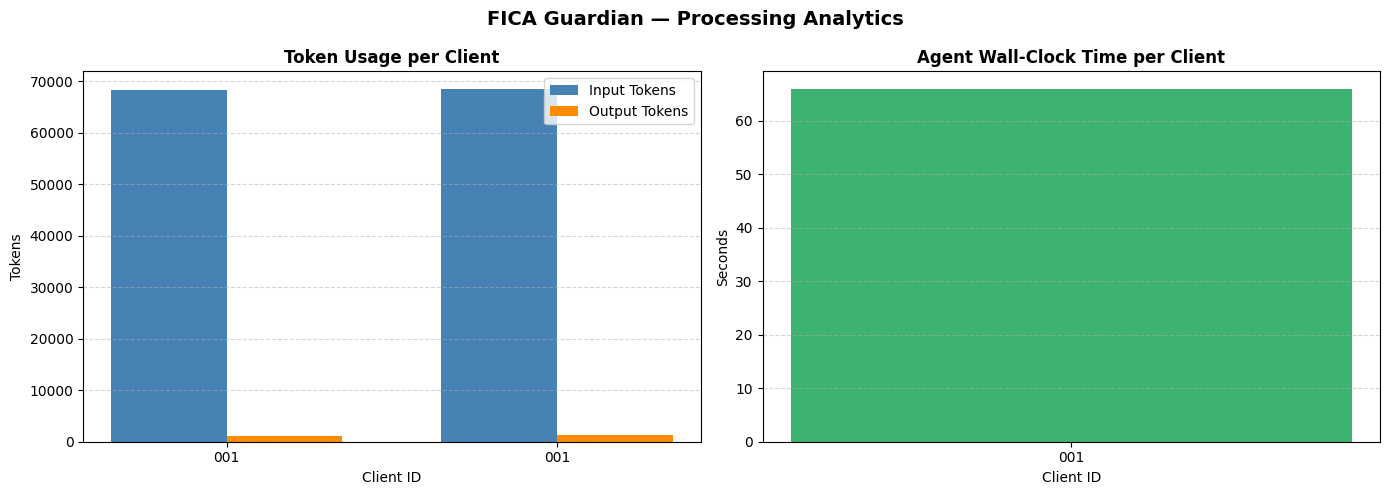

Analytics chart saved to: ./fica_analytics.png


In [41]:
# ---------------------------------------------------------------------------
# TOKEN USAGE & PERFORMANCE ANALYTICS
#
# Data source: audit_middleware.audit_records populated by KYCAuditMiddleware
#
# Outputs:
#   1. Per-client token breakdown table (input, output, total, LLM served)
#   2. Per-client wall-clock time
#   3. Gate tool latency breakdown
#   4. Aggregate token consumption vs estimated daily Groq quota remaining
#   5. Bar chart: token usage per client
# ---------------------------------------------------------------------------

records = audit_middleware.audit_records

if not records:
    print("No audit records found. Ensure the agent ran with KYCAuditMiddleware attached.")
else:
    # --- Per-Client Summary Table -------------------------------------------
    summary_rows = []
    for rec in records:
        models_used = list({mc["model"] for mc in rec["model_calls"]})
        summary_rows.append({
            "Client ID"         : rec["client_id"],
            "Model Calls"       : len(rec["model_calls"]),
            "Input Tokens"      : rec["total_input_tokens"],
            "Output Tokens"     : rec["total_output_tokens"],
            "Total Tokens"      : rec["total_tokens"],
            "Wall Clock (s)"    : rec["wall_clock_sec"],
            "LLM Served"        : ", ".join(models_used) if models_used else "unknown",
        })

    df_summary = pd.DataFrame(summary_rows)
    print("=== Per-Client Token Usage ===")
    print(df_summary.to_string(index=False))

    # --- Aggregate Stats ----------------------------------------------------
    total_tokens_consumed   = df_summary["Total Tokens"].sum()
    groq_daily_limit        = 500_000   # Conservative free-tier daily limit
    estimated_remaining     = max(0, groq_daily_limit - total_tokens_consumed)
    avg_tokens_per_client   = df_summary["Total Tokens"].mean()

    print(f"\n=== Aggregate Token Analytics ===")
    print(f"  Total tokens consumed    : {total_tokens_consumed:,}")
    print(f"  Groq daily quota (est.)  : {groq_daily_limit:,}")
    print(f"  Estimated quota remaining: {estimated_remaining:,}")
    print(f"  Avg tokens per client    : {avg_tokens_per_client:,.0f}")
    print(f"  Estimated clients/day    : {int(groq_daily_limit / avg_tokens_per_client) if avg_tokens_per_client > 0 else 'N/A'}")

    # --- Gate Tool Latency --------------------------------------------------
    tool_rows = []
    for rec in records:
        for tc in rec["tool_calls"]:
            tool_rows.append({
                "Client ID" : rec["client_id"],
                "Tool"      : tc["tool"],
                "Verdict"   : tc["verdict"],
                "Latency ms": tc["latency_ms"],
            })

    if tool_rows:
        df_tools = pd.DataFrame(tool_rows)
        print(f"\n=== Gate Tool Latency (ms) ===")
        print(df_tools.groupby("Tool")["Latency ms"].agg(["mean", "max", "min"]).round(1).to_string())

    # --- Bar Chart: Token Usage Per Client ----------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Token breakdown per client
    clients = df_summary["Client ID"].astype(str)
    x       = range(len(clients))
    width   = 0.35

    axes[0].bar([i - width/2 for i in x], df_summary["Input Tokens"],
                width, label="Input Tokens",  color="steelblue")
    axes[0].bar([i + width/2 for i in x], df_summary["Output Tokens"],
                width, label="Output Tokens", color="darkorange")
    axes[0].set_title("Token Usage per Client", fontweight="bold")
    axes[0].set_xlabel("Client ID")
    axes[0].set_ylabel("Tokens")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(clients)
    axes[0].legend()
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    # Wall-clock time per client
    axes[1].bar(clients, df_summary["Wall Clock (s)"], color="mediumseagreen")
    axes[1].set_title("Agent Wall-Clock Time per Client", fontweight="bold")
    axes[1].set_xlabel("Client ID")
    axes[1].set_ylabel("Seconds")
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    plt.suptitle("FICA Guardian — Processing Analytics", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("./fica_analytics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Analytics chart saved to: ./fica_analytics.png")

## Section 9: Test Harness Verification

In [42]:
# ---------------------------------------------------------------------------
# TEST HARNESS
#
# Validates that actual agent verdicts match the expected outcomes defined
# in the project specification. Surfaces deviations for investigation.
# ---------------------------------------------------------------------------

EXPECTED_OUTCOMES = {
    "001": {"verdict": "APPROVED"      , "scenario": "Standard — no anomalies"},
    "002": {"verdict": "REJECTED"      , "scenario": "PoR date > 90 days"},
    "003": {"verdict": "CRITICAL_ALERT", "scenario": "Barcode name != OCR name"},
    "004": {"verdict": "FLAG_EDD"      , "scenario": "PEP database hit"},
    "005": {"verdict": "MANUAL_REVIEW" , "scenario": "PO Box on PoR vs physical address"},
}

print("=" * 65)
print("  FICA GUARDIAN — TEST HARNESS RESULTS")
print("=" * 65)
print(f"{'Client':<10} {'Scenario':<35} {'Expected':<17} {'Actual':<17} {'Pass?'}")
print("-" * 65)

all_pass = True
for verdict in all_verdicts:
    cid      = verdict.client_id
    expected = EXPECTED_OUTCOMES.get(cid, {}).get("verdict", "UNKNOWN")
    scenario = EXPECTED_OUTCOMES.get(cid, {}).get("scenario", "")
    actual   = verdict.final_verdict
    passed   = (actual == expected)
    if not passed:
        all_pass = False
    status_str = "PASS" if passed else "FAIL"
    print(f"{cid:<10} {scenario:<35} {expected:<17} {actual:<17} {status_str}")

print("-" * 65)
print(f"Overall result: {'ALL TESTS PASSED' if all_pass else 'ONE OR MORE TESTS FAILED'}")
print("=" * 65)

  FICA GUARDIAN — TEST HARNESS RESULTS
Client     Scenario                            Expected          Actual            Pass?
-----------------------------------------------------------------
001        Standard — no anomalies             APPROVED          MANUAL_REVIEW     FAIL
-----------------------------------------------------------------
Overall result: ONE OR MORE TESTS FAILED
